In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns


In [8]:
from google.colab import files

uploaded = files.upload()

Saving mymoviedb.csv to mymoviedb.csv


In [10]:
df = pd.read_csv("mymoviedb.csv", lineterminator= '\n')


In [11]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9823,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9824,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9825,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


# Exploration Summary

 .We have a dataframe consisting of 9,827 rows and 9 columns.

 .Our dataset looks tidy with no NaN values or duplicate values.

 .Release_Date column needs to be converted to datetime format and only the year should be extracted.

 .Original_Language and Poster_Url columns are not very useful for analysis and can be removed.

 .There are noticeable outliers in the Popularity column.

.Vote_Average should be categorized for better analysis.

.Genre column contains comma-separated values and extra white spaces that need to be handled and casted into category.

#Change the Dataset of Release_date


In [13]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtypes)

datetime64[ns]


In [14]:
df['Release_Date'] = df['Release_Date'].dt.year

# Check datatype
df['Release_Date'].dtypes

dtype('int32')

In [15]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


#Droping columns


In [20]:
cols = ['Overview', 'Original_Language', 'Poster_Url']

In [ ]:
df.drop(cols, axis=1, inplace=True)

In [25]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

#Categorizing Vote_Average Column
We would cut the Vote_Average values and make 4 categories:

not_popular

below_avg

average

popular

In [26]:
def catigorize_col(df, col, labels):

    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')

    return df

In [27]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

catigorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [29]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2412
below_avg,2398


In [31]:
df.dropna(inplace=True)

df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [32]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [34]:
df['Genre'] = df['Genre'].str.split(', ')                                           # split the strings into lists

                                                                                     # explode the lists
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [36]:
df['Genre'] = df['Genre'].astype('category')                                           #casting column into category

df['Genre'].dtypes                                                                     # confirming changes


CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [37]:
df.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19


#Data Visualization

In [39]:
sns.set_style('whitegrid')

ques 1 : what is the most frequent genre of movies released on Netflix?

In [40]:
df['Genre'].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


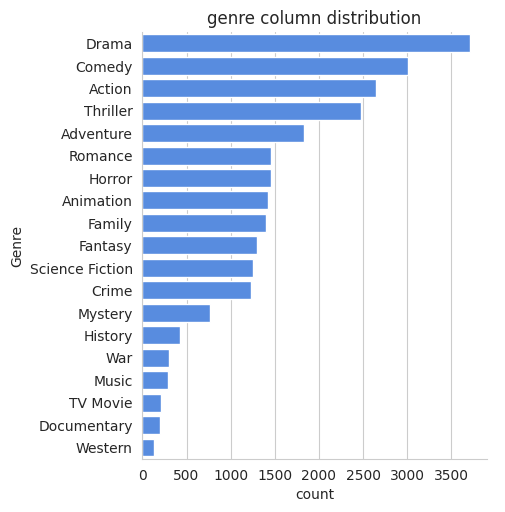

In [41]:
# visualizing genre column
sns.catplot(y = 'Genre', data = df, kind = 'count',
            order = df['Genre'].value_counts().index,
            color = '#4287f5')

plt.title('genre column distribution')
plt.show()

ques 2 : which genre has highest vote?

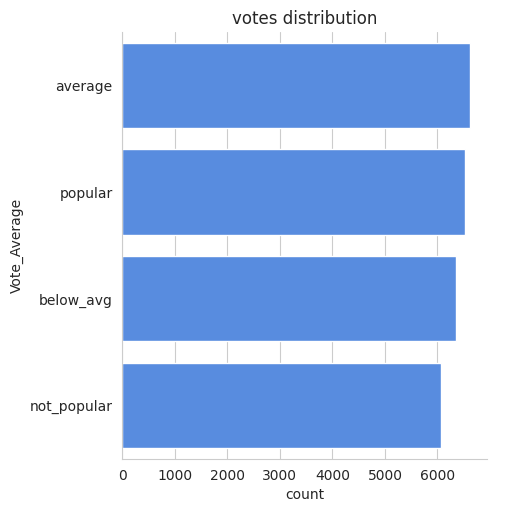

In [42]:
sns.catplot(y = 'Vote_Average', data = df, kind = 'count',                              # visualizing vote_average column
            order = df['Vote_Average'].value_counts().index,
            color = '#4287f5')

plt.title('votes distribution')
plt.show()

ques 3 : Which movies get highest popularity? What it is genre ?

In [43]:
max_popularity = df[df['Popularity'] == df['Popularity'].max()]
max_popularity

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


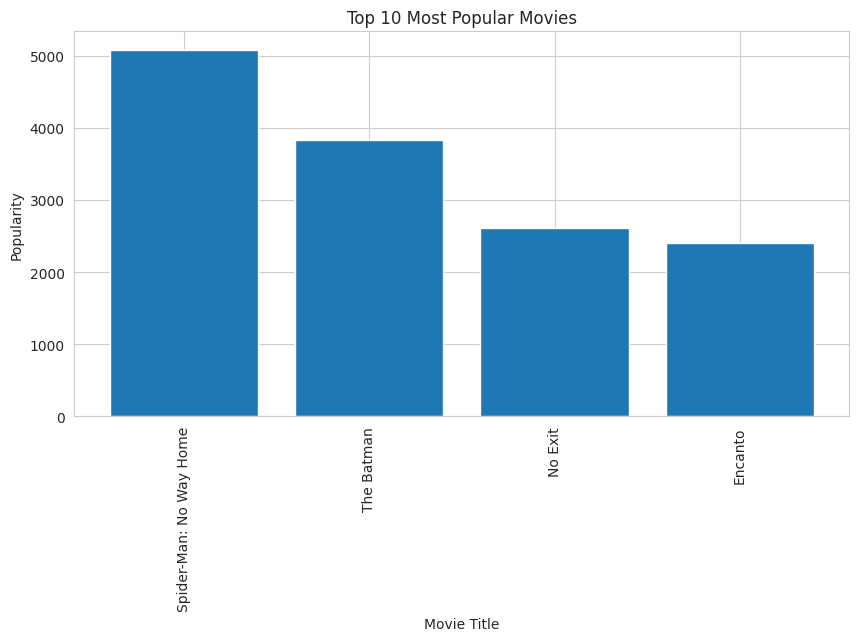

In [46]:
top10 = df.sort_values(by='Popularity', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Title'], top10['Popularity'])
plt.xticks(rotation=90)
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Movie Title')
plt.ylabel('Popularity')
plt.show()

ques 4 : Which movies got lowest popularity? What its genre?

In [47]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


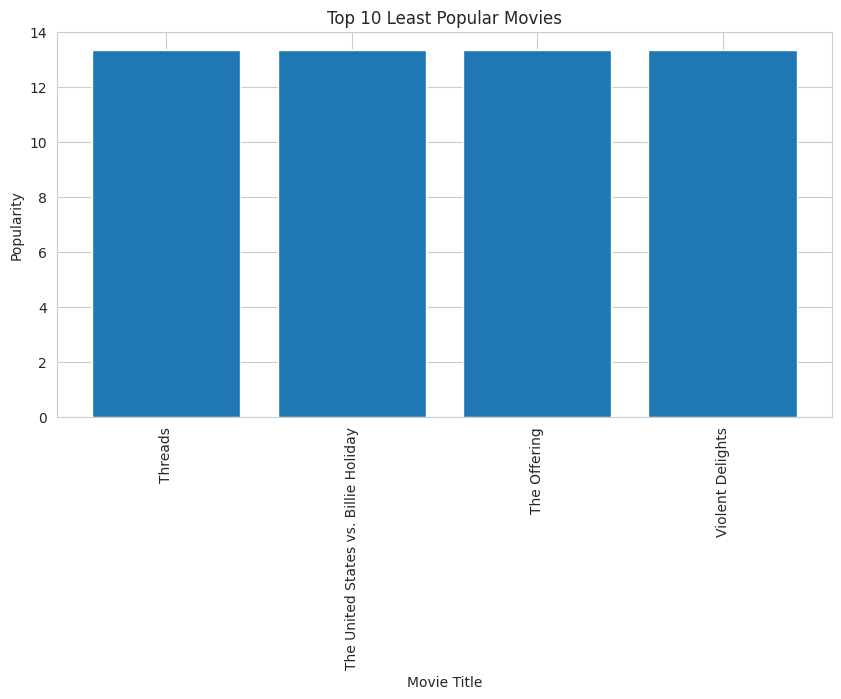

In [48]:
least10 = df.sort_values(by='Popularity', ascending=True).head(10)

plt.figure(figsize=(10,5))
plt.bar(least10['Title'], least10['Popularity'])
plt.xticks(rotation=90)
plt.title('Top 10 Least Popular Movies')
plt.xlabel('Movie Title')
plt.ylabel('Popularity')
plt.show()

Ques 5 : Which year has the most filmed movies?

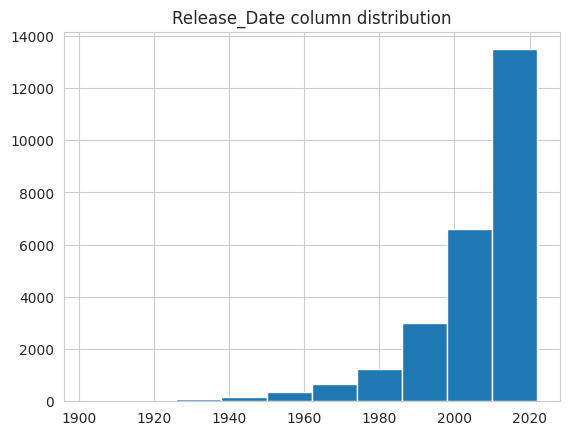

In [49]:
df['Release_Date'].hist()
plt.title('Release_Date column distribution')
plt.show()

In [ ]:
# Conclusion

# Q1: What is the most frequent genre in the dataset?
# Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among 19 other genres.

# Q2: What genres has highest votes?
# We have 25.5% of our dataset with popular votes (6520 rows). Drama again gets the highest popularity among fans by having more than 18.5% movies from the popular vote category.

# Q3: What movie got the highest popularity? What's its genre?
# Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action, Adventure, and Science Fiction.

# Q3: What movie got the lowest popularity? What's its genre?
# The United States, Thread has the lowest popularity rate in our dataset and it has genres of Music, Drama, War, Sci-Fi, and History.

# Q4: Which year has the most filmed movies?
# Year 2020 has the highest filming rate in our dataset.